# Fig 4A: DNA Self-Attention (Enhanced Colors)

Regenerate fig4a_dna_self_attention.png with better color contrast.

**Problem**: Original uses `viridis` without vmax capping → most of heatmap is dark purple.

**Fix**:
- `inferno` colormap (better contrast in low-value regions)
- `PowerNorm(gamma=0.4)` to compress dynamic range
- `vmax` at 97th percentile to prevent outlier domination

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm
from pathlib import Path
import glob

# Publication figure settings
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['font.size'] = 8
plt.rcParams['axes.titlesize'] = 9
plt.rcParams['axes.labelsize'] = 8
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['pdf.fonttype'] = 42

In [3]:
# ── Load NB6 attention matrices ──
NB6_OUTPUT = Path('/content/drive/MyDrive/cdt_outputs/morris_deep_attention')
OUTPUT_DIR = Path('/content/drive/MyDrive/cdt_outputs/morris_pub_figures')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

npz_files = sorted(glob.glob(str(NB6_OUTPUT / 'deep_attention_matrices_*.npz')))
NPZ_PATH = Path(npz_files[-1])
print(f'Loading: {NPZ_PATH.name}')

npz = np.load(NPZ_PATH, allow_pickle=True)

# GFI1B DNA self-attention
dna_self_l1 = npz['GFI1B_dna_self_L0']  # [nhead, 896, 896]
dna_self_l2 = npz['GFI1B_dna_self_L1']  # [nhead, 896, 896]

l1_avg = dna_self_l1.mean(axis=0)  # [896, 896]
l2_avg = dna_self_l2.mean(axis=0)

print(f'Layer 1: shape={l1_avg.shape}, range=[{l1_avg.min():.4f}, {l1_avg.max():.4f}]')
print(f'Layer 2: shape={l2_avg.shape}, range=[{l2_avg.min():.4f}, {l2_avg.max():.4f}]')
print(f'Layer 1 percentiles: 50%={np.percentile(l1_avg, 50):.4f}, 95%={np.percentile(l1_avg, 95):.4f}, 99%={np.percentile(l1_avg, 99):.4f}')
print(f'Layer 2 percentiles: 50%={np.percentile(l2_avg, 50):.4f}, 95%={np.percentile(l2_avg, 95):.4f}, 99%={np.percentile(l2_avg, 99):.4f}')

Loading: deep_attention_matrices_20260208_181845.npz
Layer 1: shape=(896, 896), range=[0.0000, 0.6047]
Layer 2: shape=(896, 896), range=[0.0000, 0.0853]
Layer 1 percentiles: 50%=0.0000, 95%=0.0013, 99%=0.0202
Layer 2 percentiles: 50%=0.0003, 95%=0.0049, 99%=0.0085


## Compare colormaps and normalization

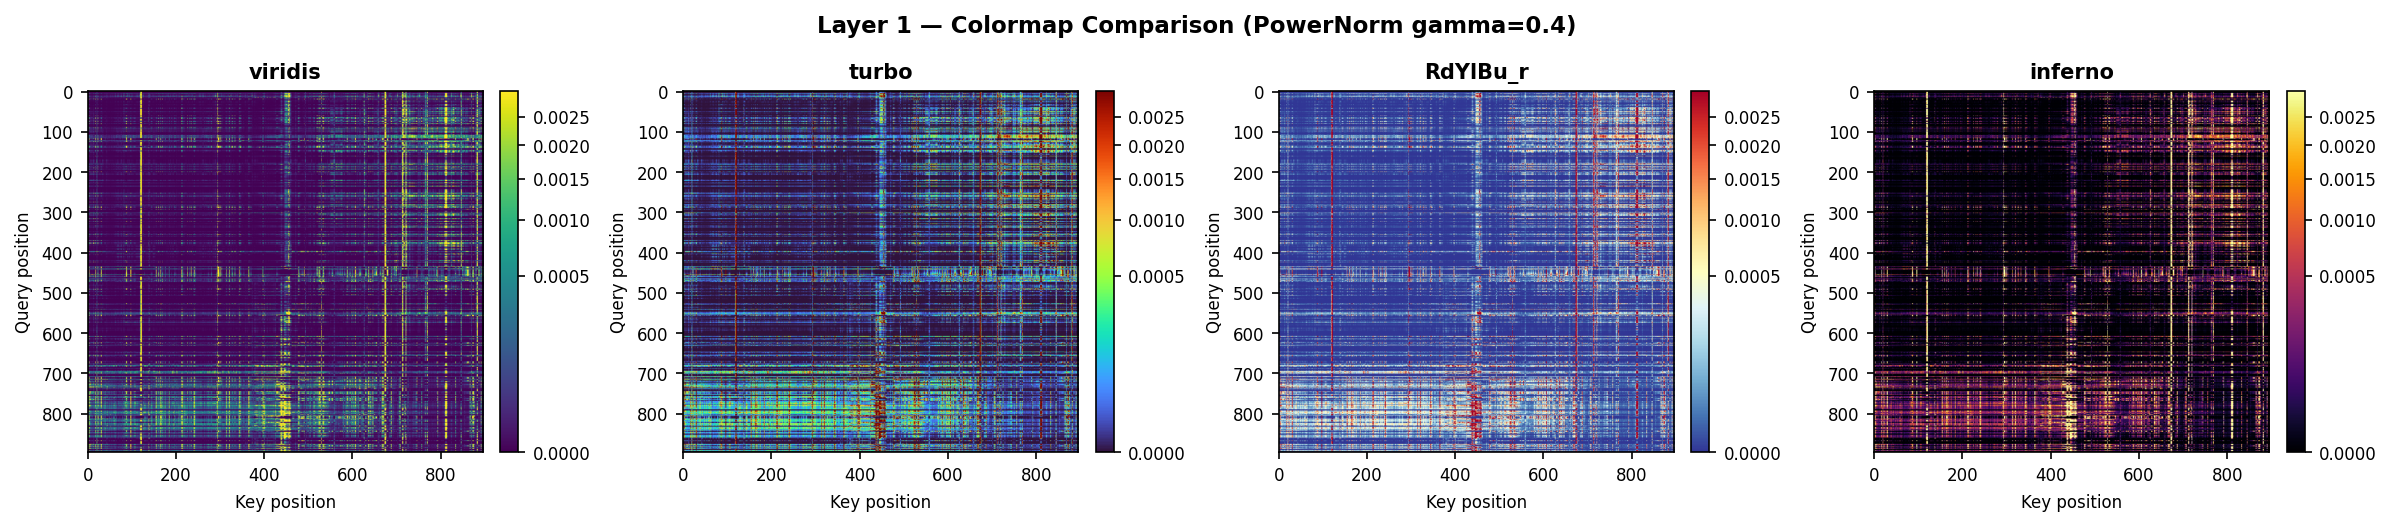

Pick your favorite colormap, then run the next cell.


In [4]:
# ── Colormap comparison (Layer 1 only for quick preview) ──
cmaps = ['viridis', 'turbo', 'RdYlBu_r', 'inferno']
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))

for ax, cmap in zip(axes, cmaps):
    vmax = np.percentile(l1_avg, 97)
    im = ax.imshow(l1_avg, cmap=cmap, aspect='auto',
                   norm=PowerNorm(gamma=0.4, vmin=0, vmax=vmax))
    ax.set_title(cmap, fontsize=10, fontweight='bold')
    ax.set_xlabel('Key position')
    ax.set_ylabel('Query position')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('Layer 1 — Colormap Comparison (PowerNorm gamma=0.4)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()
print("Pick your favorite colormap, then run the next cell.")

## Generate publication figure

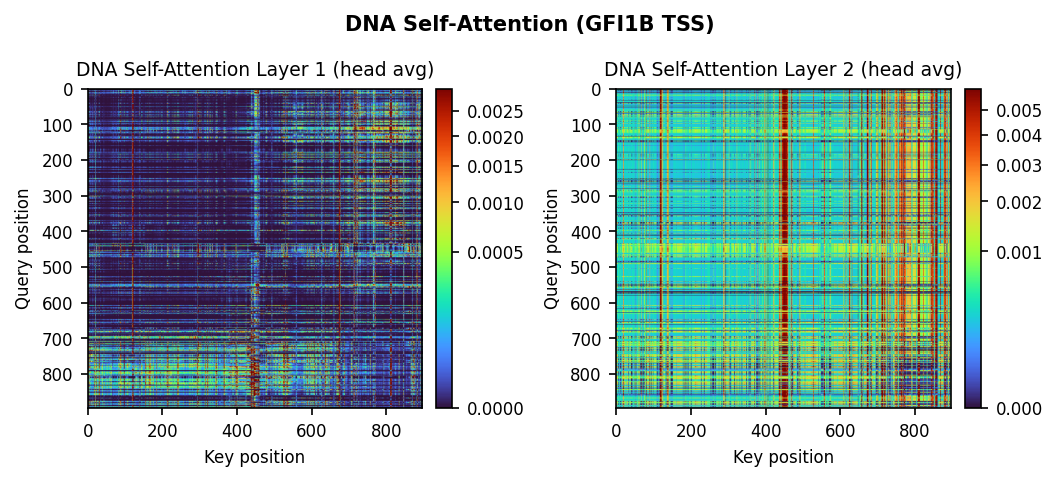

Saved with cmap=turbo, gamma=0.4


In [5]:
# ══════════════════════════════════════════════════════════════
# Publication Figure 4A
# Change CMAP here after comparing above
# ══════════════════════════════════════════════════════════════
CMAP = 'turbo'    # Recommended: blue → green → yellow → red, no black
GAMMA = 0.4       # < 1 boosts low values; try 0.3-0.5

fig, axes = plt.subplots(1, 2, figsize=(7.1, 3.2))

for ax, data, title in zip(axes,
                            [l1_avg, l2_avg],
                            ['DNA Self-Attention Layer 1 (head avg)',
                             'DNA Self-Attention Layer 2 (head avg)']):
    vmax = np.percentile(data, 97)
    im = ax.imshow(data, cmap=CMAP, aspect='auto',
                   norm=PowerNorm(gamma=GAMMA, vmin=0, vmax=vmax))
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('Key position')
    ax.set_ylabel('Query position')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('DNA Self-Attention (GFI1B TSS)', fontsize=10, fontweight='bold')
plt.tight_layout()

# Save
plt.savefig(OUTPUT_DIR / 'fig4a_dna_self_attention.png', dpi=300, bbox_inches='tight')
plt.savefig(OUTPUT_DIR / 'fig4a_dna_self_attention.pdf', dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved with cmap={CMAP}, gamma={GAMMA}')

## Download

After downloading, place locally at:
```
cp ~/Downloads/fig4a_dna_self_attention.png figures/main/fig4a_dna_self_attention.png
```